# Cleaning customers data

In [336]:
import pandas as pd 

customers = pd.read_csv("../Data/raw/customers.csv")
customers.info()
customers


<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   customer_id        100400 non-null  int64
 1   first_name         100400 non-null  str  
 2   last_name          100400 non-null  str  
 3   age                100400 non-null  str  
 4   province           100400 non-null  str  
 5   city               99796 non-null   str  
 6   employment_status  97293 non-null   str  
 7   income             97263 non-null   str  
 8   customer_since     100400 non-null  str  
dtypes: int64(1), str(8)
memory usage: 6.9 MB


,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,NaN,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,KwaZulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,MOLEFE,33,KwaZulu-Natal,Durban,Employed,"28,803.42",2013-02-10
...,...,...,...,...,...,...,...,...,...
100395,28691,Zanele,Pillay,27,Gauteng,Pretoria,Employed,8793.76,2022-04-07
100396,3743,Thabo,Molefe,41,KwaZulu-Natal,Durban,Retired,18720.9,2025-09-04
100397,91741,Ethan,Dlamini,18,Gauteng,Midrand,Employed,28779.63,2014-08-25
100398,2999,Emma,Botha,41,Gauteng,Pretoria,Retired,14252.29,2014-02-20


In [337]:

#Converting customer_since data type to datetime and fixing date format
#customers['customer_since'] = customers['customer_since'].str.replace("-", "/")

customers['customer_since'] = pd.to_datetime(
    customers['customer_since'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100400 non-null  int64         
 1   first_name         100400 non-null  str           
 2   last_name          100400 non-null  str           
 3   age                100400 non-null  str           
 4   province           100400 non-null  str           
 5   city               99796 non-null   str           
 6   employment_status  97293 non-null   str           
 7   income             97263 non-null   str           
 8   customer_since     100180 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 6.9 MB


In [338]:
customers['customer_since'] = customers['customer_since'].fillna(pd.Timestamp('1900-01-01'))

In [339]:
customers.income = customers.income.fillna('0.0')

In [340]:
#Changing income data type and removing "R" and "," and spaces

customers['income'] = customers['income'].str.replace(",", "")
customers['income'] = customers['income'].str.replace(" ", "")
customers['income'] = customers['income'].str.replace("R", "")
customers['income'] = customers['income'].astype(float)
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100400 non-null  int64         
 1   first_name         100400 non-null  str           
 2   last_name          100400 non-null  str           
 3   age                100400 non-null  str           
 4   province           100400 non-null  str           
 5   city               99796 non-null   str           
 6   employment_status  97293 non-null   str           
 7   income             100400 non-null  float64       
 8   customer_since     100400 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 6.9 MB


In [341]:
customers.employment_status = customers.employment_status.str.strip()
customers.employment_status = customers.employment_status.str.capitalize()

customers.employment_status.unique()


<StringArray>
['Employed', nan, 'Retired', 'Student', 'Self-employed', 'Unemployed', 'Nan']
Length: 7, dtype: str

In [342]:
# replacing null values with"Nan"
import numpy as np
customers = customers.replace(np.nan,"Nan")

In [343]:

# Replace "unknown" variations with missing values
customers['age'] = customers['age'].replace(
    ['unknown', 'Unknown', 'UNKNOWN', 'unkown', -4, 150, 999, 0],
    np.nan
)

# Convert to numeric
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')

# Fill missing ages with the median
customers['age'] = customers['age'].fillna(customers['age'].median())

# Convert to integer
customers['age'] = customers['age'].astype(int)


customers['age'].unique()

customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100400 entries, 0 to 100399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100400 non-null  int64         
 1   first_name         100400 non-null  str           
 2   last_name          100400 non-null  str           
 3   age                100400 non-null  int64         
 4   province           100400 non-null  str           
 5   city               100400 non-null  str           
 6   employment_status  100400 non-null  str           
 7   income             100400 non-null  float64       
 8   customer_since     100400 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 6.9 MB


In [344]:
#Removing duplicates

customers = customers.drop_duplicates()

customers[customers.duplicated() == True]


,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since


In [345]:
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,KwaZulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,MOLEFE,33,KwaZulu-Natal,Durban,Employed,28803.42,2013-10-02
...,...,...,...,...,...,...,...,...,...
100388,40659,Sophia,Botha,39,eastern cape,Gqeberha,Employed,15477.05,2025-02-03
100390,93542,NOAH,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26
100392,89556,Lerato,Botha,33,KwaZulu-Natal,Durban,Unemployed,21132.74,2021-08-28
100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19


In [346]:

customers.first_name = customers.first_name.str.title()

customers.last_name = customers.last_name.str.title()
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,KwaZulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,Molefe,33,KwaZulu-Natal,Durban,Employed,28803.42,2013-10-02
...,...,...,...,...,...,...,...,...,...
100388,40659,Sophia,Botha,39,eastern cape,Gqeberha,Employed,15477.05,2025-02-03
100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26
100392,89556,Lerato,Botha,33,KwaZulu-Natal,Durban,Unemployed,21132.74,2021-08-28
100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19


In [347]:
customers.city = customers.city.str.strip()
#removing the white and space bar spaces 
customers.city = customers.city.str.replace(r'\s+', ' ', regex=True)
customers.city = customers.city.str.title()

customers.city.unique()


<StringArray>
[    'Bloemfontein',         'Mbombela',       'Rustenburg',
           'Durban',          'Tzaneen',         'Pretoria',
      'Thohoyandou',           'George',            'Paarl',
          'Midrand',     'Johannesburg', 'Pietermaritzburg',
        'Cape Town',          'Kuruman',        'Bethlehem',
      'East London',         'Gqeberha',          'Mthatha',
        'Kimberley',        'Polokwane',     'Richards Bay',
           'Soweto',     'Stellenbosch',       'Emalahleni',
         'Mahikeng',           'Welkom',       'Klerksdorp',
         'Upington',          'Secunda',              'Nan']
Length: 30, dtype: str

In [348]:
customers.province = customers.province.str.strip()
customers.province = customers.province.str.replace(r'\s+', ' ', regex=True)
customers.province = customers.province.str.title()

customers.province.unique()

<StringArray>
[   'Free State',    'Mpumalanga',    'North West', 'Kwazulu-Natal',
       'Limpopo',       'Gauteng',  'Western Cape', 'Northern Cape',
  'Eastern Cape']
Length: 9, dtype: str

In [349]:
customers

,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since
0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24
1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25
2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18
3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21
4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02
...,...,...,...,...,...,...,...,...,...
100388,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03
100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26
100392,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28
100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19


In [350]:
customers.info()

<class 'pandas.DataFrame'>
Index: 100090 entries, 0 to 100394
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100090 non-null  int64         
 1   first_name         100090 non-null  str           
 2   last_name          100090 non-null  str           
 3   age                100090 non-null  int64         
 4   province           100090 non-null  str           
 5   city               100090 non-null  str           
 6   employment_status  100090 non-null  str           
 7   income             100090 non-null  float64       
 8   customer_since     100090 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 7.6 MB


In [352]:
customers.to_csv("../Data/processed/cleanedCustomers2.csv")

# Cleaning Branches

In [ ]:
import pandas as pd 

branches = pd.read_csv("../Data/raw/branches.csv")
branches.info()
branches

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_id    250 non-null    int64
 1   branch_name  250 non-null    str  
 2   province     247 non-null    str  
 3   city         249 non-null    str  
 4   branch_type  250 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.9 KB


,branch_id,branch_name,province,city,branch_type
0,1,Mzansi Branch 001,Western Cape,Cape Town,Suburban
1,2,Mzansi Branch 002,Mpumalanga,Emalahleni,Rural
2,3,Mzansi Branch 003,Limpopo,Polokwane,Urban
3,2,Mzansi Branch 004,Eastern Cape,Gqeberha,Urban
4,5,Mzansi Branch 005,Eastern Cape,East London,Urban
...,...,...,...,...,...
245,246,Mzansi Branch 246,Western Cape,Stellenbosch,Urban
246,247,Mzansi Branch 247,Mpumalanga,MBOMBELA,Urban
247,248,Mzansi Branch 248,Eastern Cape,East London,Suburban
248,249,Mzansi Branch 249,North West,Klerksdorp,Urban


In [ ]:
#Replacing all null values with "Nan"
branches = branches.replace(np.nan,"Nan")
branches.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_id    250 non-null    int64
 1   branch_name  250 non-null    str  
 2   province     250 non-null    str  
 3   city         250 non-null    str  
 4   branch_type  250 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.9 KB


In [ ]:


branches.province = branches.province.str.strip()
#removing the white and space bar spaces 
branches.province = branches.province.str.replace(r'\s+', ' ', regex=True)
branches.province = branches.province.str.title()
branches.province.unique()

<StringArray>
[ 'Western Cape',    'Mpumalanga',       'Limpopo',  'Eastern Cape',
    'North West',           'Nan',       'Gauteng',    'Free State',
 'Northern Cape', 'Kwazulu-Natal']
Length: 10, dtype: str

In [ ]:
branches.city = branches.city.str.strip()
#removing the white and space bar spaces
branches.city = branches.city.str.replace(r'\s+', ' ', regex=True)
branches.city = branches.city.str.title()

branches.city.unique()

<StringArray>
[       'Cape Town',       'Emalahleni',        'Polokwane',
         'Gqeberha',      'East London',       'Rustenburg',
           'George',         'Mbombela',     'Johannesburg',
        'Bethlehem',        'Kimberley',          'Secunda',
         'Mahikeng',           'Welkom',         'Pretoria',
     'Bloemfontein',          'Kuruman',      'Thohoyandou',
       'Klerksdorp', 'Pietermaritzburg',            'Paarl',
           'Soweto',         'Upington',          'Midrand',
          'Mthatha',           'Durban',     'Richards Bay',
     'Stellenbosch',          'Tzaneen',              'Nan']
Length: 30, dtype: str

In [ ]:
#Checking duplicates
branches[branches.duplicated() == True]

,branch_id,branch_name,province,city,branch_type


In [ ]:
#Ch
branches.branch_type = branches.branch_type.str.strip()
#removing the white and space bar spaces
branches.branch_type = branches.branch_type.str.replace(r'\s+', ' ', regex=True)
branches.branch_type = branches.branch_type.str.title()
branches.branch_type.unique()

<StringArray>
['Suburban', 'Rural', 'Urban']
Length: 3, dtype: str

In [ ]:
#branches[branches.city.isin(['Mbombela', 'Bethlehem', 'Rustenburg'])]
# branches[(branches['city'] == 'Mbombela') & (branches['province'].isna())].fillna("Mpumalanga")
# branches[(branches['city'] == 'Rustenburg') & (branches['province'].isna())].fillna("North West")
# branches[(branches['city'] == 'Bethlehem') & (branches['province'].isna())].fillna("Free State")

#Filling the null provinces checking their cities
province_map = {

'Mbombela': 'Mpumalanga',

'Rustenburg': 'North West',

'Bethlehem': 'Free State'

}

for city, province in province_map.items():
 branches.loc[

(branches['city'] == city) & (branches['province'].isna()),

'province'

] = province


In [ ]:

# Check the mode of cities in the Northern Cape
mode_city = branches.loc[
branches['province'] == 'Northern Cape',
'city'
].mode()
mode_city

branches[(branches['province'] == 'Northern Cape') & (branches['city'].isna())].fillna(mode_city)

,branch_id,branch_name,province,city,branch_type


In [ ]:
#Filling the null city in Northern Cape with the mode of the cities in Northern cape
branches[(branches['province'] == 'Northern Cape') & (branches['city'].isna())].fillna(mode_city)



,branch_id,branch_name,province,city,branch_type


In [ ]:
branches.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_id    250 non-null    int64
 1   branch_name  250 non-null    str  
 2   province     250 non-null    str  
 3   city         250 non-null    str  
 4   branch_type  250 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.9 KB


In [ ]:
branches.to_csv("../Data/processed/cleanedBranches.csv")

# Cleaning Accounts

In [ ]:
import pandas as pd 

accounts = pd.read_csv("../Data/raw/accounts.csv")
accounts.info()
accounts

<class 'pandas.DataFrame'>
RangeIndex: 125375 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   account_id      125375 non-null  int64
 1   customer_id     124756 non-null  str  
 2   account_type    124715 non-null  str  
 3   branch_id       125375 non-null  int64
 4   account_status  124735 non-null  str  
 5   opened_date     125375 non-null  str  
dtypes: int64(2), str(4)
memory usage: 5.7 MB


,account_id,customer_id,account_type,branch_id,account_status,opened_date
0,1,74688,Business,150,Active,2017-06-28
1,2,21183,Savings,54,Active,2021-01-26
2,3,93719,Cheque,164,Active,2023-01-13
3,4,6909,cheque,36,active,2017-12-30
4,5,45524,Cheque,86,Active,2021-02-21
...,...,...,...,...,...,...
125370,89439,85991,Savings,229,Active,2024-08-27
125371,21550,57898,Savings,206,Active,2016-10-18
125372,2529,31546,Savings,21,Dormant,2022-05-06
125373,116956,2412,Business,164,Dormant,2021-11-25


In [ ]:
#Droping the row with null customer_id

accounts = accounts.drop(
    accounts[accounts['customer_id'].isna()].index
)

accounts[accounts['customer_id'].isna()]


,account_id,customer_id,account_type,branch_id,account_status,opened_date


In [ ]:

#Fixing the CustomerID
accounts[accounts['customer_id'] == 'INVALID_CUST_0000210']


,account_id,customer_id,account_type,branch_id,account_status,opened_date
786,787,INVALID_CUST_0000210,Cheque,76,Active,2016-12-07


In [ ]:
#Fixing the CustomerID
accounts['customer_id'] = accounts['customer_id'].str.replace(
'INVALID_CUST_', '',
regex=False
)

In [ ]:
accounts['customer_id'] = accounts['customer_id'].astype('int64')
accounts.info()

<class 'pandas.DataFrame'>
Index: 124756 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   account_id      124756 non-null  int64
 1   customer_id     124756 non-null  int64
 2   account_type    124101 non-null  str  
 3   branch_id       124756 non-null  int64
 4   account_status  124119 non-null  str  
 5   opened_date     124756 non-null  str  
dtypes: int64(3), str(3)
memory usage: 6.7 MB


In [ ]:
accounts['opened_date'] = pd.to_datetime(
    accounts['opened_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
    
).fillna(pd.Timestamp("1900-01-01"))
accounts.info()


<class 'pandas.DataFrame'>
Index: 124756 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   account_id      124756 non-null  int64         
 1   customer_id     124756 non-null  int64         
 2   account_type    124101 non-null  str           
 3   branch_id       124756 non-null  int64         
 4   account_status  124119 non-null  str           
 5   opened_date     124756 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 6.7 MB


In [ ]:
# replacing null values with"Nan"
import numpy as np
accounts = accounts.replace(np.nan,"Nan")

accounts.info()

<class 'pandas.DataFrame'>
Index: 124756 entries, 0 to 125374
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   account_id      124756 non-null  int64         
 1   customer_id     124756 non-null  int64         
 2   account_type    124756 non-null  str           
 3   branch_id       124756 non-null  int64         
 4   account_status  124756 non-null  str           
 5   opened_date     124756 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 6.7 MB


In [ ]:
accounts.account_type = accounts.account_type.str.strip()

accounts.account_type = accounts.account_type.str.title()

accounts.account_type.unique()

<StringArray>
['Business', 'Savings', 'Cheque', 'Credit', 'Nan']
Length: 5, dtype: str

In [ ]:
accounts.account_status = accounts.account_status.str.strip()

accounts.account_status = accounts.account_status.str.title()
accounts.account_status.unique()

<StringArray>
['Active', 'Dormant', 'Closed', 'Open', 'Nan', 'Terminated']
Length: 6, dtype: str

In [ ]:
#Checking duplicates
accounts[accounts.duplicated() == True]

,account_id,customer_id,account_type,branch_id,account_status,opened_date
125000,58886,33232,Savings,222,Active,2018-07-21
125001,106269,14324,Savings,81,Active,2022-05-07
125002,103202,53155,Credit,210,Closed,2022-01-04
125003,11742,49296,Savings,117,Active,2024-12-18
125004,121303,84598,Credit,109,Active,2024-01-26
...,...,...,...,...,...,...
125370,89439,85991,Savings,229,Active,2024-08-27
125371,21550,57898,Savings,206,Active,2016-10-18
125372,2529,31546,Savings,21,Dormant,2022-06-05
125373,116956,2412,Business,164,Dormant,2021-11-25


In [ ]:
#Removing duplicates

accounts = accounts.drop_duplicates()

accounts[accounts.duplicated() == True]

,account_id,customer_id,account_type,branch_id,account_status,opened_date


In [ ]:
accounts.to_csv("../Data/processed/cleanedAccounts2.csv", index=False)

In [ ]:
accounts.info()

<class 'pandas.DataFrame'>
Index: 124401 entries, 0 to 125363
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   account_id      124401 non-null  int64         
 1   customer_id     124401 non-null  int64         
 2   account_type    124401 non-null  str           
 3   branch_id       124401 non-null  int64         
 4   account_status  124401 non-null  str           
 5   opened_date     124401 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 6.6 MB


# Merging datasets Customers, Accounts and Transactions for Customer features


In [ ]:
import pandas as pd
accounts = pd.read_csv("../Data/processed/cleanedAccounts2.csv", parse_dates=['opened_date'])
transactions = pd.read_csv("../Data/final/transactions_clean_final.csv", parse_dates=['transaction_date'])
customers = pd.read_csv("../Data/processed/cleanedCustomers2.csv", parse_dates=['customer_since'])

In [ ]:
#Displaying transaction rows with null 'merchant_id'

transactions[transactions['merchant_id'].isna()]

,Unnamed: 0,transaction_id,account_id,merchant_id,transaction_date,transaction_type,channel,amount,currency,description,transaction_size,transaction_days,transaction_year


In [ ]:
# filling null merchant_id with unkown
transactions["merchant_id"] = transactions["merchant_id"].fillna("Unknown")


In [ ]:
# Extracts the year, month, day, and weekday from customer_since into separate columns.
cleanedCustomers2 = customers.assign(
    Start_Year=customers['customer_since'].dt.year,
    Start_Month=customers['customer_since'].dt.month,
    Start_Day=customers['customer_since'].dt.day,
    Weekday=customers['customer_since'].dt.weekday
)

cleanedCustomers2


,Unnamed: 0,customer_id,first_name,last_name,age,province,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday
0,0,1,Emma,Naidoo,42,Free State,Bloemfontein,Employed,11418.82,2022-11-24,2022,11,24,3
1,1,2,Amelia,Mokoena,49,Mpumalanga,Mbombela,Nan,31336.45,2024-12-25,2024,12,25,2
2,2,3,Nomsa,Jacobs,34,North West,Rustenburg,Employed,11351.46,2020-03-18,2020,3,18,2
3,3,4,Sipho,Dlamini,35,Kwazulu-Natal,Durban,Retired,30291.15,2025-10-21,2025,10,21,1
4,4,5,Emma,Molefe,33,Kwazulu-Natal,Durban,Employed,28803.42,2013-10-02,2013,10,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100085,100388,40659,Sophia,Botha,39,Eastern Cape,Gqeberha,Employed,15477.05,2025-02-03,2025,2,3,0
100086,100390,93542,Noah,Jacobs,41,Gauteng,Johannesburg,Student,0.00,2016-12-26,2016,12,26,0
100087,100392,89556,Lerato,Botha,33,Kwazulu-Natal,Durban,Unemployed,21132.74,2021-08-28,2021,8,28,5
100088,100393,55437,Noah,Botha,56,Gauteng,Soweto,Retired,31652.89,2016-08-19,2016,8,19,4


In [ ]:
# Changing 'account_id' data type to str. because I can't I wanted to merge two datasets a
accounts.account_id = accounts.account_id.astype(str)
#transactions.info()

In [ ]:
trans_acc = pd.merge(accounts,transactions, how='inner', on="account_id")
trans_acc.info()

<class 'pandas.DataFrame'>
RangeIndex: 994216 entries, 0 to 994215
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account_id        994216 non-null  str           
 1   customer_id       994216 non-null  int64         
 2   account_type      994216 non-null  str           
 3   branch_id         994216 non-null  int64         
 4   account_status    994216 non-null  str           
 5   opened_date       994216 non-null  datetime64[us]
 6   Unnamed: 0        994216 non-null  int64         
 7   transaction_id    994216 non-null  int64         
 8   merchant_id       994216 non-null  str           
 9   transaction_date  994216 non-null  datetime64[us]
 10  transaction_type  994216 non-null  str           
 11  channel           994216 non-null  str           
 12  amount            994216 non-null  float64       
 13  currency          994216 non-null  str           
 14  description    

In [ ]:
trans_acc_cus =  pd.merge(trans_acc,cleanedCustomers2, how='inner', on="customer_id")
trans_acc_cus.info()

<class 'pandas.DataFrame'>
RangeIndex: 995146 entries, 0 to 995145
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   account_id         995146 non-null  str           
 1   customer_id        995146 non-null  int64         
 2   account_type       995146 non-null  str           
 3   branch_id          995146 non-null  int64         
 4   account_status     995146 non-null  str           
 5   opened_date        995146 non-null  datetime64[us]
 6   Unnamed: 0_x       995146 non-null  int64         
 7   transaction_id     995146 non-null  int64         
 8   merchant_id        995146 non-null  str           
 9   transaction_date   995146 non-null  datetime64[us]
 10  transaction_type   995146 non-null  str           
 11  channel            995146 non-null  str           
 12  amount             995146 non-null  float64       
 13  currency           995146 non-null  str           
 14 

In [ ]:
# Droping indexes becuase I forgot to remove them when saving csv
trans_acc_cus = trans_acc_cus.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
trans_acc_cus.info()

<class 'pandas.DataFrame'>
RangeIndex: 995146 entries, 0 to 995145
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   account_id         995146 non-null  str           
 1   customer_id        995146 non-null  int64         
 2   account_type       995146 non-null  str           
 3   branch_id          995146 non-null  int64         
 4   account_status     995146 non-null  str           
 5   opened_date        995146 non-null  datetime64[us]
 6   transaction_id     995146 non-null  int64         
 7   merchant_id        995146 non-null  str           
 8   transaction_date   995146 non-null  datetime64[us]
 9   transaction_type   995146 non-null  str           
 10  channel            995146 non-null  str           
 11  amount             995146 non-null  float64       
 12  currency           995146 non-null  str           
 13  description        995146 non-null  str           
 14 

In [ ]:
#Customer Transaction Count
trans_acc_cus['cus_trans_count'] = (trans_acc_cus.groupby('customer_id')['transaction_id'].transform('count'))
trans_acc_cus

,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,province,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,Western Cape,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,Eastern Cape,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11


In [ ]:
#Customer Total Transaction Value
trans_acc_cus['cus_total_trans_val'] = (trans_acc_cus.groupby('customer_id')['amount'].transform('sum'))


trans_acc_cus

,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,city,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,Paarl,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,Mthatha,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55


In [ ]:
#Customer_average_transaction
trans_acc_cus['customer_avg_trans'] = (trans_acc_cus.groupby('customer_id')['amount'].transform('mean'))
trans_acc_cus

,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,employment_status,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,Employed,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,Self-employed,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636


In [ ]:
#customer_max_transaction
trans_acc_cus['cus_max_trans'] = (trans_acc_cus.groupby(['customer_id', 'first_name', 'last_name'])['amount'].transform('max'))
trans_acc_cus


,account_id,customer_id,account_type,branch_id,account_status,opened_date,transaction_id,merchant_id,transaction_date,transaction_type,...,income,customer_since,Start_Year,Start_Month,Start_Day,Weekday,cus_trans_count,cus_total_trans_val,customer_avg_trans,cus_max_trans
0,1,74688,Business,150,Active,2017-06-28,38129,7983.0,2026-06-13,Purchase,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
1,1,74688,Business,150,Active,2017-06-28,78511,3641.0,2026-03-12,Transfer,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
2,1,74688,Business,150,Active,2017-06-28,174428,12684.0,2025-10-25,Payment,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
3,1,74688,Business,150,Active,2017-06-28,278121,6301.0,2026-04-01,Purchase,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
4,1,74688,Business,150,Active,2017-06-28,410586,11238.0,2026-04-07,Transfer,...,70840.56,2021-03-06,2021,3,6,5,15,22841.99,1522.799333,8085.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995141,112560,93769,Savings,76,Active,2018-12-18,606794,8369.0,2025-09-06,Purchase,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995142,112560,93769,Savings,76,Active,2018-12-18,621781,5556.0,2025-05-13,Withdrawal,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995143,112560,93769,Savings,76,Active,2018-12-18,697041,Unknown,2026-05-11,Purchase,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00
995144,112560,93769,Savings,76,Active,2018-12-18,929758,8809.0,2026-07-10,Transfer,...,68428.07,2018-01-31,2018,1,31,2,11,7462.55,678.413636,1239.00


In [ ]:
trans_acc_cus.info()

<class 'pandas.DataFrame'>
RangeIndex: 995146 entries, 0 to 995145
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   account_id           995146 non-null  str           
 1   customer_id          995146 non-null  int64         
 2   account_type         995146 non-null  str           
 3   branch_id            995146 non-null  int64         
 4   account_status       995146 non-null  str           
 5   opened_date          995146 non-null  datetime64[us]
 6   transaction_id       995146 non-null  int64         
 7   merchant_id          995146 non-null  str           
 8   transaction_date     995146 non-null  datetime64[us]
 9   transaction_type     995146 non-null  str           
 10  channel              995146 non-null  str           
 11  amount               995146 non-null  float64       
 12  currency             995146 non-null  str           
 13  description          9951

In [ ]:
# trans_acc_cus[["customer_id", "cus_trans_count", "cus_total_trans_val", "customer_avg_trans", "cus_max_trans"]].drop_duplicates().merge(customers).to_csv("data/final/customers_final.csv", index=False)
# trans_acc_cus

In [ ]:
customers_final = (
    cleanedCustomers2
    .drop(columns=["Unnamed: 0"], errors="ignore")
    .merge(
        trans_acc_cus[
            [
                "customer_id",
                "cus_trans_count",
                "cus_total_trans_val",
                "customer_avg_trans",
                "cus_max_trans"
            ]
        ].drop_duplicates(),
        on="customer_id",
        how="left"
    )
)

customers_final.to_csv("../Data/final/customers_final.csv", index=False)

In [ ]:
customers_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 100090 entries, 0 to 100089
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          100090 non-null  int64         
 1   first_name           100090 non-null  str           
 2   last_name            100090 non-null  str           
 3   age                  100090 non-null  int64         
 4   province             100090 non-null  str           
 5   city                 100090 non-null  str           
 6   employment_status    100090 non-null  str           
 7   income               100090 non-null  float64       
 8   customer_since       100090 non-null  datetime64[us]
 9   Start_Year           100090 non-null  int32         
 10  Start_Month          100090 non-null  int32         
 11  Start_Day            100090 non-null  int32         
 12  Weekday              100090 non-null  int32         
 13  cus_trans_count      7123

# Business Intelligence Risk and management 

In [ ]:
import pandas as pd
customers = pd.read_csv('../Data/processed/cleanedCustomers2.csv', parse_dates=['customer_since'])
transactions = pd.read_csv("../Data/final/transactions_clean_final.csv", parse_dates=['transaction_date'])
merchants = pd.read_csv("../Data/processed/merchants_cleaned.csv")
fraud_label = pd.read_csv("../Data/processed/fraud_label_cleaned.csv")
transactions = transactions.drop(columns=["Unnamed: 0"], errors="ignore")
customers = customers.drop(columns=["Unnamed: 0"], errors="ignore") 
merchants = merchants.drop(columns=["Unnamed: 0"], errors="ignore")
fraud_label = fraud_label.drop(columns=["Unnamed: 0"], errors="ignore")
transactions["merchant_id"] = transactions["merchant_id"].astype(str)
merchants["merchant_id"] = merchants["merchant_id"].astype(str)
fraud_label["transaction_id"] = fraud_label["transaction_id"].astype(str)
transactions["transaction_id"] = transactions["transaction_id"].astype(str)


In [ ]:
merchants

,merchant_id,merchant_name,merchant_category,province,city,risk_rating
0,1,merchant 00001,Online Services,Free State,Bethlehem,Low
1,2,Merchant 00002,Grocery,Mpumalanga,Secunda,Low
2,3,Merchant 00003,Clothing,Limpopo,Polokwane,Medium
3,4,Merchant 00004,Grocery,Mpumalanga,Mbombela,Low
4,5,Merchant 00005,Travel,Free State,Bloemfontein,Medium
...,...,...,...,...,...,...
19995,19996,Merchant 19996,Online Services,Mpumalanga,Mbombela,Low
19996,19997,Merchant 19997,Restaurant,Kwazulu-Natal,Durban,Low
19997,19998,Merchant 19998,Grocery,Kwazulu-Natal,Richards Bay,Low
19998,19999,Merchant 19999,Grocery,Free State,Welkom,Low


In [ ]:
merchants['risk_rating'].unique()

<StringArray>
['Low', 'Medium', 'High', 'Critical', 'High Risk', 'Nan', 'Unknown']
Length: 7, dtype: str

In [ ]:
#How many transactions are potentially suspicious?

suspicious_transactions = merchants[
    merchants['risk_rating'].isin(['High', 'Critical', 'Unknown'])
]

# Count transactions in each risk category
risk_counts = (
    suspicious_transactions['risk_rating']
    .value_counts()
    .reindex(['Critical', 'High', 'Unknown'], fill_value=0)
)

# Display the counts
print(risk_counts)

risk_rating
Critical      17
High        2088
Unknown       18
Name: count, dtype: int64


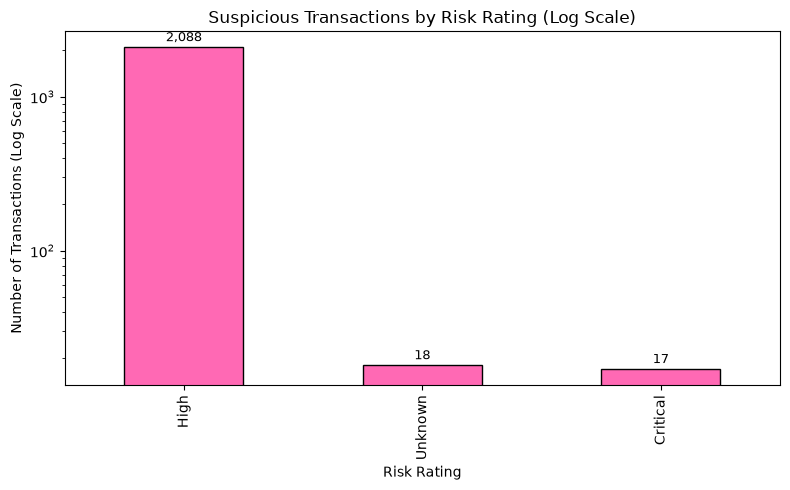

In [ ]:
import matplotlib.pyplot as plt

# Sort from highest to lowest count
risk_counts = risk_counts.sort_values(ascending=False)

ax = risk_counts.plot(
    kind='bar',
    figsize=(8, 5),
    color='hotpink',
    edgecolor='black'
)

plt.yscale('log')  # Compresses large differences between categories

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,  # x-position
        height * 1.05,                  # slightly above bar
        f'{int(height):,}',             # format with commas
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Suspicious Transactions by Risk Rating (Log Scale)')
plt.ylabel('Number of Transactions (Log Scale)')
plt.xlabel('Risk Rating')

plt.tight_layout()
plt.show()

In [ ]:
#What percentage of transactions are labelled fraudulent?

fraud_count = (fraud_label['is_fraud'] == 1.0).sum()

fraud_count_per = round((fraud_count / len(fraud_label)) * 100, 2)
print(f"Percentage of Fraudulent Transactions: {fraud_count_per}")


Percentage of Fraudulent Transactions: 0.64


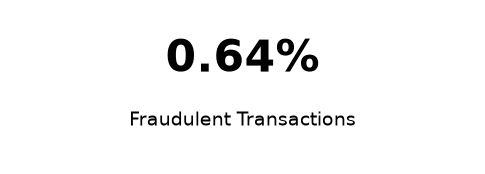

In [359]:
import matplotlib.pyplot as plt

# figsize controls the width and height of the KPI card
fig, ax = plt.subplots(figsize=(6, 2))

# Remove axes, ticks, and borders to create a clean KPI display
ax.axis('off')

# Positioned in the center of the figure
ax.text(
    0.5, 0.6,                        # (x, y) position in figure coordinates
    f'{fraud_count_per}%',           # Fraud percentage value
    fontsize=32,                     # font size 
    fontweight='bold',               
    ha='center',                    
    color='black'                  # Use red to highlight fraud risk
)
# Add a descriptive label below the KPI value
# This explains what the percentage represents
ax.text(
    0.5, 0.25,                       # Position below the KPI value
    'Fraudulent Transactions',       # KPI description
    fontsize=14,                    
    ha='center'                    
)

plt.show()

In [ ]:
fraud_label

fraud_label["transaction_id"] = (
  fraud_label["transaction_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)


In [ ]:
# merging transactions and fraud_lebel for to show Which channel has the highest fraud rate?
trans_fra = pd.merge(
     transactions, fraud_label,  on="transaction_id",
         how="left"
     )


In [ ]:
channel_summary = (
    trans_fra
    .groupby('channel')
    .agg(
        total_transactions=('transaction_id', 'count'),
        fraudulent_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean')
    )
    .sort_values('fraud_rate', ascending=False)
)

channel_summary['fraud_rate'] *= 100
channel_summary

,total_transactions,fraudulent_transactions,fraud_rate
channel,,,
App,79233,736.0,0.929751
Online,296514,2611.0,0.881448
Nan,11912,76.0,0.638602
Mobile,217661,1076.0,0.494813
Branch,79214,387.0,0.489100
Atm,148566,719.0,0.484452
Pos,168023,794.0,0.473044


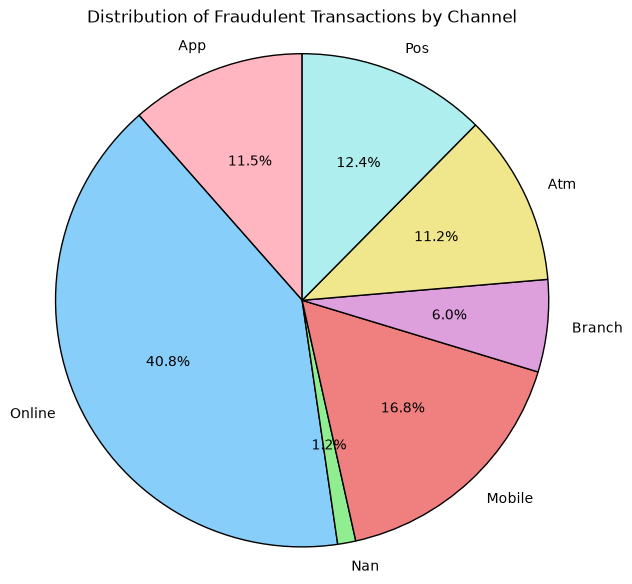

In [365]:
import matplotlib.pyplot as plt

colors = [
    "#FFB6C1",  # light pink
    "#87CEFA",  # light sky blue
    "#90EE90",  # light green
    "#F08080",  # light coral
    "#DDA0DD",  # plum
    "#F0E68C",  # khaki
    "#AFEEEE",  # pale turquoise
    "#FFDAB9",  # peach
    "#B0E0E6",  # powder blue
    "#E6E6FA",  # lavender
]

plt.figure(figsize=(7, 7))

plt.pie(
    channel_summary['fraudulent_transactions'],
    labels=channel_summary.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Distribution of Fraudulent Transactions by Channel')
plt.axis('equal')

plt.show()

In [ ]:
# Which transaction type has the highest fraud rate?
transaction_type_fraud = (
    trans_fra
    .groupby('transaction_type')
    .agg(
        total_transactions=('transaction_id', 'count'),
        fraudulent_transactions=('is_fraud', 'sum'),
        fraud_rate=('is_fraud', 'mean')
    )
    .reset_index()
    .sort_values('fraud_rate', ascending=False)
)

# Convert fraud rate to percentage
transaction_type_fraud['fraud_rate'] = (
    transaction_type_fraud['fraud_rate'] * 100
).round(2)

transaction_type_fraud


,transaction_type,total_transactions,fraudulent_transactions,fraud_rate
4,Transfer,180845,1415.0,0.78
1,Payment,150393,1153.0,0.77
3,Refund,49849,298.0,0.60
2,Purchase,420925,2424.0,0.58
5,Withdrawal,98961,561.0,0.57
0,Deposit,100150,548.0,0.55


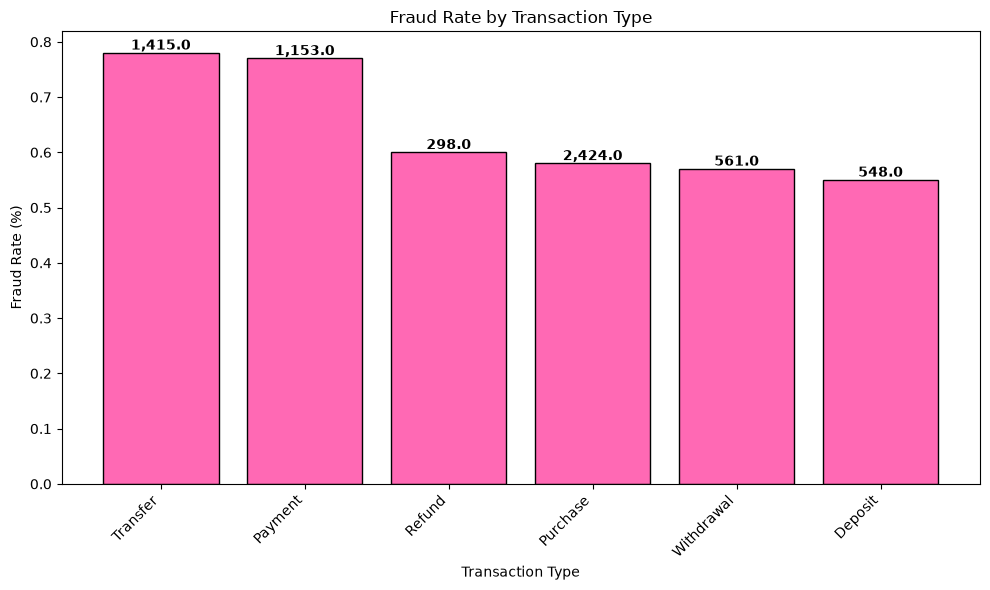

In [ ]:
import matplotlib.pyplot as plt

# Sort transaction types from highest to lowest fraud rate
plot_data = transaction_type_fraud.sort_values(
    'fraud_rate',
    ascending=False
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars (height still represents fraud rate)
bars = ax.bar(
    plot_data['transaction_type'],
    plot_data['fraud_rate'],
    color='hotpink',
    edgecolor='black'
)

# Add fraud count labels on top of each bar
for bar, fraud_count in zip(
    bars,
    plot_data['fraudulent_transactions']
):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{fraud_count:,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )
ax.set_title('Fraud Rate by Transaction Type')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Fraud Rate (%)')

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Which merchants catgories associated with the highest risk?
high_risk_merchants = merchants[
    merchants['risk_rating'].isin(['High', 'Critical'])
]

# Count occurrences by merchant
merchant_risk_counts = (
    high_risk_merchants
    .groupby('merchant_category')
    .size()
    .sort_values(ascending=False)
    .head(10)  # Top 10 highest-risk merchants
)

merchant_risk_counts

merchant_category
Healthcare         232
Grocery            223
Fuel               220
Clothing           214
Restaurant         210
Other              205
Electronics        202
Entertainment      202
Online Services    193
Travel             189
dtype: int64

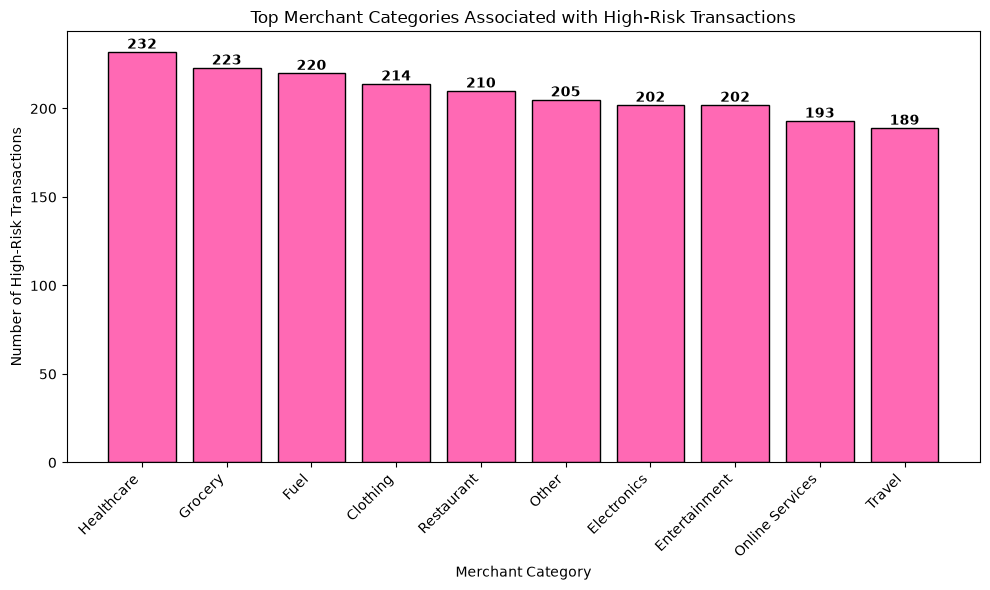

In [ ]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
bars = ax.bar(
    merchant_risk_counts.index,
    merchant_risk_counts.values,
    color='hotpink',
    edgecolor='black'
)

# Add transaction counts on top of each bar
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Add title and labels
ax.set_title('Top Merchant Categories Associated with High-Risk Transactions')
ax.set_xlabel('Merchant Category')
ax.set_ylabel('Number of High-Risk Transactions')

# Rotate category names if needed
plt.xticks(rotation=45, ha='right')

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

In [ ]:
#Which provinces have the highest risk?
high_risk_provinces = merchants[
    merchants['risk_rating'].isin(['High', 'Critical'])
]

# Count high-risk transactions by province
province_risk_counts = (
    high_risk_provinces
    .groupby('province')
    .size()
    .sort_values(ascending=False)
)

province_risk_counts

province
Limpopo          258
North West       257
Kwazulu-Natal    256
Western Cape     247
Gauteng          222
Eastern Cape     220
Free State       220
Mpumalanga       215
Northern Cape    210
dtype: int64

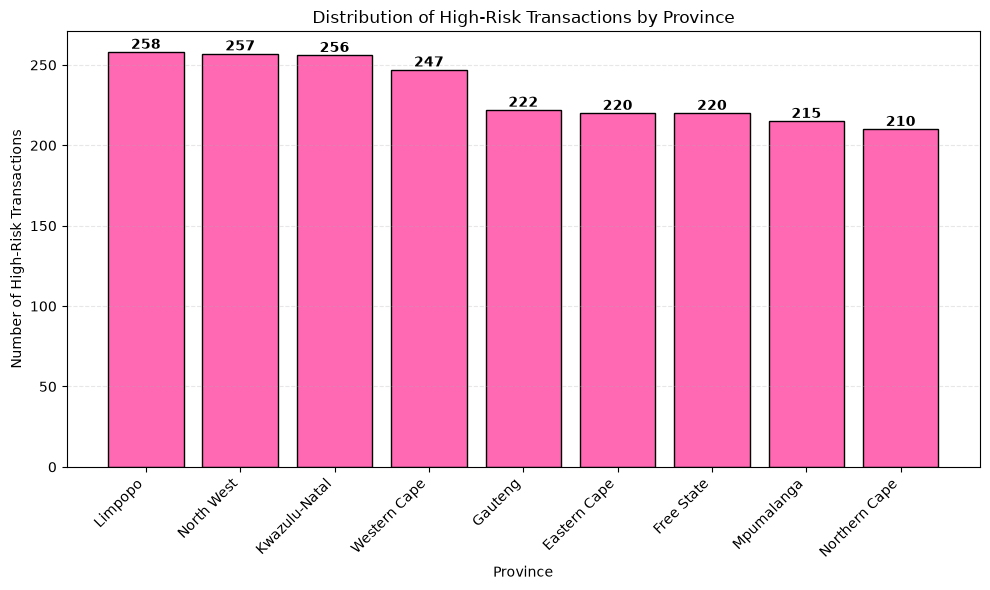

In [ ]:
import matplotlib.pyplot as plt

# Sort provinces from highest to lowest
province_risk_counts = province_risk_counts.sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
bars = ax.bar(
    province_risk_counts.index,
    province_risk_counts.values,
    color='hotpink',
    edgecolor='black'
)

# Add transaction counts on top of each bar
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Add title and labels
ax.set_title('Distribution of High-Risk Transactions by Province')
ax.set_xlabel('Province')
ax.set_ylabel('Number of High-Risk Transactions')

# Rotate province names for readability
plt.xticks(rotation=45, ha='right')

# Add subtle gridlines
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

# Fraud Analysis

In [ ]:
import pandas as pd

fraud_label = pd.read_csv('../Data/processed/fraud_label_cleaned.csv')
fraud_label["transaction_id"] = fraud_label["transaction_id"].astype(str)
fraud_label.info()

<class 'pandas.DataFrame'>
RangeIndex: 999059 entries, 0 to 999058
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  999059 non-null  str    
 1   is_fraud        999059 non-null  float64
 2   fraud_reason    981157 non-null  str    
dtypes: float64(1), str(2)
memory usage: 22.9 MB


In [ ]:
# Fraud rate
fraud_rate = fraud_label['is_fraud'].mean() * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")


Fraud Rate: 0.64%


In [ ]:
fraud_label[fraud_label['is_fraud'] == 1]

,transaction_id,is_fraud,fraud_reason
205,206.0,1.0,unknown pattern
310,311.0,1.0,unusual channel
479,480.0,1.0,unusual channel
560,561.0,1.0,unknown pattern
566,567.0,1.0,high-risk merchant
...,...,...,...
998411,999351.0,1.0,unusual channel
998587,999527.0,1.0,unknown pattern
998618,999558.0,1.0,unusual amount
998898,999840.0,1.0,unknown pattern


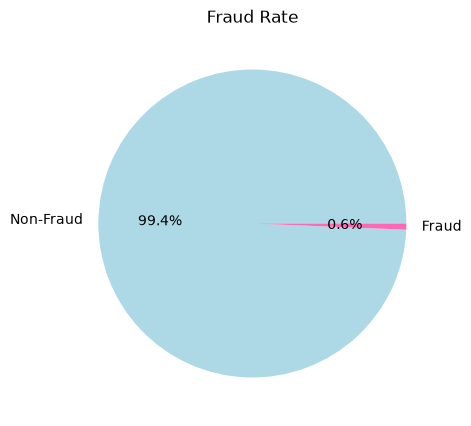

In [ ]:
import matplotlib.pyplot as plt

counts = fraud_label['is_fraud'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    counts,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.1f%%',
    colors=['lightblue', 'hotpink']
)
plt.title('Fraud Rate')
plt.show()

In [354]:

fraud_label["transaction_id"] = (
  fraud_label["transaction_id"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)


In [357]:
# merging transactions and fraud_lebel for to show Which channel has the highest fraud rate?
trans_fra = pd.merge(
      transactions, fraud_label,  on="transaction_id",
          how="left"
      )
trans_fra[trans_fra['is_fraud'] == 1]


,transaction_id,account_id,merchant_id,transaction_date,transaction_type,channel,amount,currency,description,transaction_size,transaction_days,transaction_year,is_fraud,fraud_reason
205,206,29107,8071.0,2025-12-31,Purchase,Online,3908.25,R,Online purchase,Low,Wednesday,2025,1.0,unknown pattern
310,311,41637,7509.0,2025-01-20,Purchase,Atm,668.16,R,Transfer,Low,Monday,2025,1.0,unusual channel
479,480,15460,14533.0,2025-02-23,Refund,App,1875.68,R,Cash withdrawal,Low,Sunday,2025,1.0,unusual channel
560,561,11810,17914.0,2025-11-29,Payment,Mobile,872.21,R,Cash withdrawal,Low,Saturday,2025,1.0,unknown pattern
566,567,71602,19016.0,2025-10-21,Purchase,App,596.55,R,Bill payment,Low,Tuesday,2025,1.0,high-risk merchant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000703,263923,43198,19437.0,2026-06-17,Purchase,Pos,436.68,R,Retail purchase,Low,Wednesday,2026,1.0,unusual amount
1000750,826452,116751,11147.0,2025-03-01,Transfer,Pos,1185.28,R,Transfer,Low,Saturday,2025,1.0,rapid activity
1000816,401887,94746,Unknown,2025-07-07,Purchase,Online,1299.61,R,Online purchase,Low,Monday,2025,1.0,rapid activity
1000831,526513,80549,3999.0,2025-12-06,Purchase,Mobile,12831.45,R,Cash withdrawal,Low,Saturday,2025,1.0,rapid activity


In [358]:
fraud_province = (
    trans_fra[trans_fra['is_fraud'] == 1]
    ['province']
    .value_counts()
    .sort_values(ascending=False)
)

ax = fraud_province.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black',
    figsize=(10,5)
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Fraud by Province')
plt.ylabel('Fraud Transactions')
plt.show()

KeyError: 'province'

IndexError: index 0 is out of bounds for axis 0 with size 0

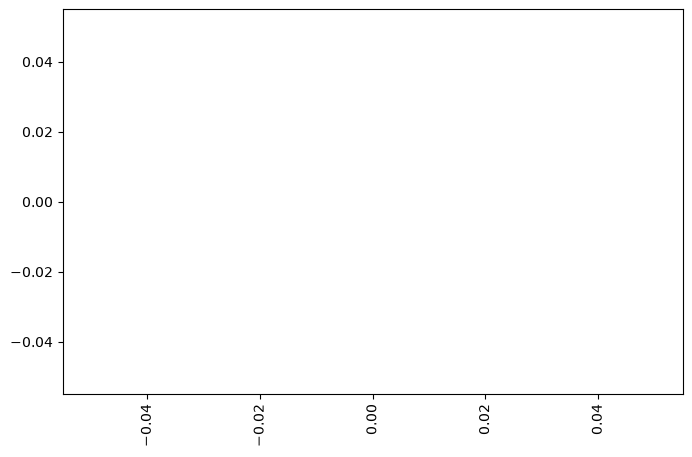

In [ ]:
fraud_channel = (
    trans_fra[trans_fra['is_fraud'] == 1]
    ['channel']
    .value_counts()
)

ax = fraud_channel.plot(
    kind='bar',
    color='hotpink',
    edgecolor='black',
    figsize=(8,5)
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Fraud by Channel')
plt.ylabel('Fraud Transactions')
plt.show()